# Global Contingency Tables: Assessing the Similarity Between Two Primary Productivity (NetPP) Products

> History | Updated Feb 2025

## Overview
This analysis compares trends over time between the legacy and an interim primary productivity (NetPP) products:

* Legacy **MODIS-Aqua** Primary Productivity Product

* Interim **VIIRS-SNPP** Primary Productivity Product

* Interim **VIIRS-NOAA20** Primary Productivity Product

## Tutorial for this notebook

For this tutorial, we will be comparing **MODIS-Aqua** and **VIIRS-NOAA20**.

The process is divided into three mainsteps:

### 1. Long-Term Linear Trends in NetPP

We have already calculated the long-term linear trend for NetPP using linear regression analysis. Key details of the analysis include:

* **Pixel-by-Pixel Analysis:** Linear regression was applied over time to each pixel for  both legacy and interim NetPP products.

* **Output Results:** Pixel-by-pixel values were produced for:
    * The slope of the linear trend.
    
    * The number of observations used to calculate the trend (n).

    * The p-values for statistical significance.

* **Input Data:** Monthly NetPP data spanning a 5-year period (2018-2022) was used, providing maximum n = 60 per pixel.

    * Only pixels with a time series containing 50% of the maximum 60 points were included in the analysis.

### 2. Constructing a Contingency Matrix

Using the results of the regression analysis, a contingency matrix is constructed to compare the trends between the legacy and interim product. Pixels are categorized by the matrix into three groups based on the sign of the slope:

1. **Positive Trend:** Increasing trend  (positive slope).

2. **Negative Trend:** Decreasing trend (negative slope).

3. **No significant Trend:** Slope not singificantly different than zero.

The contingency matrix shows the percentage of a pixels where the two NetPP products agree or disagree on the sign of the slope. 

### 3. Quantifying Agreement with Cohen's Kappa

The contingency matrix is used to compute Cohen's Kappa, a statistical measure that quantifies the level of agreement between the two NetPP products. Cohen's Kappa accounts for the agreement occuring by chance and provides a standardized metric of similarity.


## Datasets Overview

1. **Primary Productivity, MODIS-AQUA, Science Quality, Global, 9km, 2013-2022 (Monthly Composite)**
- Distributed via the West Coast Node ERDDAP dataset at the following link:
> http://localhost:8080/erddap/griddap/productivity_modis_aqua_monthly.graph

2. **Primary Productivity, VIIRS-SNPP, Science Quality, Global, 9km, 2013-2022 (Monthly Composite)**
- Distributed via the West Coast Node ERDDAP dataset at the following link:
> http://localhost:8080/erddap/griddap/productivity_viirs_snpp_monthly.graph

3. **Primary Productivity, VIIRS-NOAA20, Science Quality, Global, 9km, 2018-2022 (Monthly Composite)**
- Distributed via the West Coast Node ERDDAP dataset at the following link:
> http://localhost:8080/erddap/griddap/productivity_viirs_noaa20_monthly.graph


## Resource requirements

- **Jupyter Notebook**

- **Python 3** with the modules included within the *Import packages* section below.

- **Two trends NetCDF files**: One for MODIS-Aqua and one for either VIIRS-SNPP or VIIRS-NOAA20.


- **Internet connection**

## Import packages

In [35]:
import geopandas
import regionmask
import os
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import box

## Create global variables
Global variables are used to set up the file structure, directory paths, and template files required for making a contingency matrix.

* **BASE_DIR** is the base directory defined for the project, and the root for all other subdirectories.
* **DATA_DIR** is where the trends NetCDF files are located.
* **RESOURCES_DIR** is where the Longhurst Provinces shapefile is located.

In [36]:
# Set global variables
BASE_DIR = "/Users/madisonrichardson/netpp"
DATA_DIR = os.path.join(BASE_DIR, "data", "trends")
RESOURCES_DIR = os.path.join(BASE_DIR, "resources")

# Template for ifile
ifile_tmpl = '{}_{}_trend_month_{}_{}_{}_{}_{:03d}percent.nc'

## Create useful functions

### Function for loading trend data for the legacy and interim products

In [37]:
def load_trends(
        source_list,
        DATA_DIR, ifile_tmpl,
        ncvar,
        timeseries_type,
        startyear,
        endyear,
        prcnt_keep,
):
    """
    Load trends data for the specified sources,
    extract latitude and longitude ranges for a
    specified region, and return the processed data.

    This function iterates over a list of data sources,
    constructs file paths based on a specified template,
    oads datasets using xarray, and subsets the latitude
    and longitude data for the region of interest. It is
    designed for working with trend analysis datasets
    stored in NetCDF format.

    Args:
        source_list (list): A list of strings representing
        the names of data sources to process (e.g., ['modis', 'noaa20']).
        DATA_DIR (str): The base directory where the trend data is stored.
        ifile_tmpl (str): A format string for constructing the input file.
        ncvar (str): The variable name used in the filename template
        (e.g., 'productivity').
        timeseries_type (str): Specifies the type of time series
        data, such as raw data ('data') or anomalies ('anom').
        startyear (str): The start year for the data range in YYYY format.
        endyear (str): The end year for the data range in YYYY format.
        prcnt_keep (float): The percentage of data to retain expressed as a
        decimal (e.g., 0.5).
        rgn_wnt (list): A list defining the region of interest. The format
        is [[min_lon, max_lon], [min_lat, max_lat]] where longitude
        and latitude are specified as ranges.

    Returns:
        tuple: A tuple containing the following:
            loaded_datasets (list):
                A list of x.arrayDataset objects, each
                representing data from one source.

            region_lons (numpy.ndarray):
                Longitude values within the specified region,
                extracted from the dataset.

            region_lats (numpy.ndarray): 
                Latitude values within the specified region,
                extracted from the dataset.

    """
    loaded_datasets = []
    for source in source_list:
        # COnstruct input directory and file path
        idir = os.path.join(
            DATA_DIR
        )
        ifile = ifile_tmpl.format(
            ncvar,
            timeseries_type,
            source,
            '9km',
            startyear,
            endyear,
            int(prcnt_keep*100)
        )

        # Load dataset using xarray and append list
        loaded_data = xr.open_dataset(os.path.join(idir, ifile))
        loaded_datasets.append(loaded_data)

    # Extract lat and lon for region of interest
    region_lons = loaded_data['longitude'].data
    region_lats = loaded_data['latitude'].data

    return loaded_datasets, region_lons, region_lats


### Function for finding common grid points among the two sources

In [38]:
def get_common_points(source_list, beta_data_list, pval_data_list):
    """
    Extract common grid points with valid data between
    two sources.

    This function identifies grid points where both datasets
    contain valid data, reshapes 2D beta and p-value arrays
    into 1D vectors for comparison, and returns the beta values,
    p-values, and count of common points. Zeros in beta and
    p-values are replaced with small values (0.00001) to
    prevent issues during processing.

    Args:
        source_list (list): 
            A list of source names to compare (e.g., 'modis' or 'noaa20')
        beta_data_list (list):
            A list of 2D arrays (one per source) containing beta values
            (e.g., slope or trend data) for each grid point.
        pval_data_list (list):
            A list of 2D arrays (one per source) containing p-values
            for the statistical significance of the beta values.

    Returns:
        tuple: 
            beta_common (list):
                A list of 1D arrays, where each array contains
                beta values for grid points that are valid and
                common between the two datasets. The first array
                corresponds to 'source_list[0]', and the second
                corresponds to 'source_list[1]'.
            pval_common (list):
                A list of 1D arrays, where each array contains
                p-values for grid points that are valid and
                common between the two datasets. The order
                corresponds to 'source_list'.
            num_common (int):
                The total number of grid points that are common
                and have valid data in both datasets.
    """
    # Find the common grid points with trends
    beta_re_list = []  # reshaped beta values
    pval_re_list = []  # reshaped p-values
    ind_re_list = []  # indices of non-missing values

    for i in range(len(source_list)):
        # Reshape 2D arrays into 1D vectors
        ny, nx = beta_data_list[i].shape
        beta_re = np.reshape(beta_data_list[i].data, ny*nx)
        pval_re = np.reshape(pval_data_list[i].data, ny*nx)

        # Find indices of finites values (non-NaN)
        ind_re = np.isfinite(beta_re).nonzero()[0]

        # Replace zeros with small values to avoid issues
        trend_indices_1 = np.where(beta_re == 0.0)
        beta_re[trend_indices_1] = 0.00001
        pval_re[trend_indices_1] = 0.00001

        # Append results to lists
        beta_re_list.append(beta_re)
        pval_re_list.append(pval_re)
        ind_re_list.append(ind_re)

    # Find common indices between the two datasets
    common_indices_12 = np.isin(
        ind_re_list[0],
        ind_re_list[1]
    )  # common in source1 and source2
    common_indices_21 = np.isin(
        ind_re_list[1],
        ind_re_list[0]
    )  # common in source2 and source1

    # Extract beta and p-value data for the common grid points
    beta_common = [
        beta_re_list[0][ind_re_list[0]][common_indices_12],
        beta_re_list[1][ind_re_list[1]][common_indices_21]
    ]
    pval_common = [
        pval_re_list[0][ind_re_list[0]][common_indices_12],
        pval_re_list[1][ind_re_list[1]][common_indices_21]
    ]

    # Number of common points
    num_common = len(beta_common[0])

    return beta_common, pval_common, num_common


### Function for 2x2 Contingency Table

In [39]:
def make_2x2_contingency_table(beta_common, num_common, source_list):
    """
    Create a 2x2 contingency table comparing
    trends between two sources.

    This function compares the signs of trends (beta values) between two
    sources for common grid points and generates a 2x2 contingency table.
    The table represents the percentage of grid points that fall
    into each combination of positive and negative trends for the
    two sources.

    Args:
        beta_common (list):
            A list containing two 1D arrays of beta values
            for the grid points that are common between the
            two data sources. 'beta_common[0]' corresponds
            to the first source in 'source_list'. 
            'beta_common[1]' corresponds to the first
            source in 'source_list'. 
        num_common (int):
            The total number of grid points that are
            common between the two sources.
        source_list (list):
            A list of source names (e.g., ['modis', 'noaa20']).
            The first name corresponds to 'beta_common[0]', and
            the second corresponds to 'beta_common[1]'.

    Returns:
        tuple: A tuple containing the following:
            col_labels_2x2 (list): 
                Column labels for the contingency table
                indicating the trend direction for the first source (e.g.,
                `['MODIS $\\beta>=0$', 'MODIS $\\beta<0$']`).
            row_label_2x2 (list):
                Row labels for the contingency table
                indicating the trend direction for the second source (e.g.,
                `['NOAA20 $\\beta>=0$', 'NOAA20 $\\beta<0$']`).
            contingency_table_2x2 (numpy.ndarray):
                A 2x2 matrix representing the contingency table.
                Each cell contains the percentage of grid points
                that fall into the corresponding combination of trend
                directions.
            contingency_df_2x2 (pandas.DataFrame):
                A DataFrame representation of the contingency
                table with labeled rows and columns for easier
                visualization and interpretation.

    Contingency Table Structure:
        The table has two rows and two columns:
            Rows represent the trend direction for the second source
            (`source_list[1]`).
            Columns represent the trend direction for the first source
            (`source_list[0]`).
            Each cell represents the percentage of grid points where the
            specified trend combination is observed.

    Notes:
        Positive trends are identified as beta values greater than or equal
        to 0, and negative trends are identified as beta values less than 0.
        Percentages in the contingency table are normalized to the total
        number of common grid points (`num_common`).
        The function ensures compatibility with numpy arrays for efficient
        computation.
    """
    # Define the labels for a table
    operator_lbl = [r'$\beta>=0$', r'$\beta<0$']
    col_labels_2x2 = []
    row_label_2x2 = []
    for i in range(2):
        col_labels_2x2.append(
            '{} {}'.format(source_list[0].upper(),
                           operator_lbl[i])
        )
        row_label_2x2.append(
            '{} {}'.format(source_list[1].upper(),
                           operator_lbl[i])
        )

    # Define trend sign combinations for the contingency table
    trend_sign_combos = [[1, 1], [-1, 1], [1, -1], [-1, -1]]
    # Intialize the table as a vector
    table22_vec = np.zeros(len(trend_sign_combos))

    # Intialize the table as a vector
    trend_sign_combos = [[1, 1], [-1, 1], [1, -1], [-1, -1]]
    table22_vec = np.zeros(len(trend_sign_combos))
    for i in range(len(trend_sign_combos)):
        # Identify points with the specified trends
        sign_combo = trend_sign_combos[i]
        trend_indices_1 = np.where(sign_combo[0]*beta_common[0] > 0)[0]
        trend_indices_2 = np.where(sign_combo[1]*beta_common[1] > 0)[0]
        common_indices_sig1 = np.isin(trend_indices_1, trend_indices_2)
        num1 = len(common_indices_sig1.nonzero()[0])
        table22_vec[i] = 100*num1/num_common

    # Convert vector to 2x2 matrix
    contingency_table_2x2 = table22_vec.reshape(2, 2)

    # Create a Pandas DataFrame from the 2x2 table
    contingency_df_2x2 = pd.DataFrame(
        contingency_table_2x2, columns=col_labels_2x2
    )
    contingency_df_2x2 = contingency_df_2x2.set_index(
        np.array(row_label_2x2)
    )

    return (
        col_labels_2x2,
        row_label_2x2,
        contingency_table_2x2, 
        contingency_df_2x2
    )


### Function for 3x3 Contingency Table

In [40]:
def make_3x3_contingency_table(
        beta_common,
        pval_common,
        num_common,
        alpha,
        source_list
):
    """
    Create a 3x3 contingency table comparing trends and
    significance levels between two sources.

    This function analyzes the relationship between
    trends (beta values) and their statistical significance
    (p-values) for two datasets. It calculates percentages
    of grid points falling into combinations of non-significant 
    (n.s.), positive trends (β ≥ 0), and negative trends (β < 0) 
    for each source, with significance determined by a
    threshold `alpha`.

    Args:
        beta_common (list):
            A list containing two 1D arrays of beta values (e.g., trends or 
            slopes) for the grid points common between the two data sources.
            `beta_common[0]`: Beta values for the first source in `source_list`.
            `beta_common[1]`: Beta values for the second source in `source_list`.
        pval_common (list):
            A list containing two 1D arrays of p-values for the grid points 
            common between the two data sources.
            `pval_common[0]`: P-values for the first source in `source_list`.
            `pval_common[1]`: P-values for the second source in `source_list`.
        num_common (int):
            The total number of grid points common to both sources.
            This is used as the denominator to calculate percentages.
        alpha (float):
            The significance threshold for p-values (e.g., 0.05).
            Grid points with p-values below this threshold are
            considered statistically significant.
        source_list (list):
            A list of source names (e.g., ['modis', 'noaa20']). The first name 
            corresponds to `beta_common[0]` and `pval_common[0]`, and the second 
            corresponds to `beta_common[1]` and `pval_common[1]`.

    Returns:
        tuple: A tuple containing the following:
            col_labels_3x3 (list):
                Column labels for the contingency table, 
                indicating the trend categories for the first source 
                e.g., ['MODIS n.s.', 'MODIS $\\beta>=0$', 'MODIS $\\beta<0$']).
            row_label_3x3 (list): 
                Row labels for the contingency table, 
                indicating the trend categories for the second source 
                (e.g., ['NOAA20 n.s.', 'NOAA20 $\\beta>=0$', 'NOAA20 $\\beta<0$']).
            contingency_table_3x3 (numpy.ndarray):
                A 3x3 matrix representing the contingency table. Each cell
                contains the percentage of grid points in the corresponding
                combination of trend categories.
            contingency_df_3x3 (pandas.DataFrame): 
                A DataFrame representation of the 3x3 contingency table with
                labeled rows and columns, providing easier visualization and
                interpretation.

    Contingency Table Categories:
        Rows and columns represent the trend categories for the two sources:
            Non-significant (n.s.): 
                Grid points with p-values ≥ alpha.
            Positive trend (β ≥ 0): 
                Grid points with significant trends and 
                positive beta values.
            Negative trend (β < 0): 
                Grid points with significant trends and 
                negative beta values.
        Each cell represents the percentage of grid points that fall into 
        the combination of trend categories for the two sources.

     Notes:
        Percentages are calculated relative to the total number of common 
        grid points (`num_common`). This function assumes that `beta_common`
        and `pval_common` are aligned such that their indices correspond
        to the same grid points in both sources. Positive and negative
        trends are determined only for significant grid points
        (p-values < alpha).
    """

    # Initialize the 3x3 table
    contingency_table_3x3 = np.zeros([3, 3])

    # Define and create labels for the 3x3 matrix
    operator_lbl = ['n.s.', r'$\beta>=0$', r'$\beta<0$']
    col_labels_3x3 = []
    row_label_3x3 = []
    for i in range(3):
        col_labels_3x3.append(
            '{} {}'.format(source_list[0].upper(), operator_lbl[i])
        )
        row_label_3x3.append(
            '{} {}'.format(source_list[1].upper(), operator_lbl[i])
        )

    # Calculate values for the first row/column in non-significant cases (ns)
    ns_indices_1 = np.where(pval_common[0] >= alpha)[0]
    ns_indices_2 = np.where(pval_common[1] >= alpha)[0]
    common_indices_ns = np.isin(ns_indices_1, ns_indices_2).nonzero()[0]
    contingency_table_3x3[0, 0] = 100*len(common_indices_ns)/num_common

    # Calculate when beta1 is ns and beta2 is sig (pos/neg trends)
    # Identify indices in the beta2 where trends are sig
    sig_indices_2 = np.where(pval_common[1][ns_indices_1] < alpha)[0]

    # Extract sig beta values from beta2
    beta2_sig = beta_common[1][ns_indices_1][sig_indices_2]

    # Separate sig beta2 values into pos and neg trends
    in2_sig_pos = np.where(beta2_sig >= 0)[0]
    in2_sig_neg = np.where(beta2_sig < 0)[0]

    # Calculate the percentage of positive and negative trends for beta2
    contingency_table_3x3[1, 0] = 100*len(in2_sig_pos)/num_common  # % of pos trends when beta1 is ns
    contingency_table_3x3[2, 0] = 100*len(in2_sig_neg)/num_common  # % of neg trends when beta1 is ns

    # Calculate the percentage of positive and negative trends for beta2
    contingency_table_3x3[1, 0] = 100*len(in2_sig_pos)/num_common  # % of pos trends when beta1 is ns
    contingency_table_3x3[2, 0] = 100*len(in2_sig_neg)/num_common  # % of neg trends when beta1 is ns

    # Calculate when beta2 is ns and beta1 is sig (pos/neg trends)
    # Identify indices in the beta1 where trends are sig
    sig_indices_1 = np.where(pval_common[0][ns_indices_2] < alpha)[0]

    # Extract the sig beta1 values
    beta1_sig = beta_common[0][ns_indices_2][sig_indices_1]

    # Separate sig beta1 values into pos/neg trends
    trend_indices_2_sig_pos = np.where(beta1_sig >= 0)[0]
    trend_indices_2_sig_neg = np.where(beta1_sig < 0)[0]

    # Calculate the percentage of pos trends for beta1
    contingency_table_3x3[0, 1] = 100*len(trend_indices_2_sig_pos)/num_common  # % of pos trends when beta2 is ns
    contingency_table_3x3[0, 2] = 100*len(trend_indices_2_sig_neg)/num_common  # % of neg trends when beta2 is ns

    # Calculate when both beta1 and beta2 have sig trends
    # Identify sig trends for both datasets
    sig_indices_1 = np.where(pval_common[0] < alpha)[0]
    sig_indices_2 = np.where(pval_common[1] < alpha)[0]

    # Find common sig trends for both datsets
    common_indices_sig1 = np.isin(sig_indices_1, sig_indices_2).nonzero()[0]
    common_indices_sig2 = np.isin(sig_indices_2, sig_indices_1).nonzero()[0]

    # Extract beta values for common sig points
    reshaped_data = [
        beta_common[0][sig_indices_1][common_indices_sig1],
        beta_common[1][sig_indices_2][common_indices_sig2]
    ]

    # Define sign combinations for trends in both datasets
    trend_sign_combos = [[1, 1], [-1, 1], [1, -1], [-1, -1]]

    # Initialize a vector to store the percentages for each combo
    table33_vec = np.zeros(len(trend_sign_combos))

    # Calculate the percentage of grid points for each trend combo
    for i in range(len(trend_sign_combos)):
        sign_combo = trend_sign_combos[i]
        trend_indices_1 = np.where(sign_combo[0]*reshaped_data[0] > 0)[0]
        trend_indices_2 = np.where(sign_combo[1]*reshaped_data[1] > 0)[0]
        common_indices_sig1 = np.isin(trend_indices_1, trend_indices_2)
        num1 = len(common_indices_sig1.nonzero()[0])
        table33_vec[i] = 100*num1/num_common

    # Populate the lower-right 4 cells
    contingency_table_3x3[1:, 1:] = np.reshape(table33_vec, [2, 2])

    # Create a Pandas DataFrame from the 3x3 table
    contingency_df_3x3 = pd.DataFrame(
        contingency_table_3x3,
        columns=col_labels_3x3
    )
    contingency_df_3x3 = contingency_df_3x3.set_index(np.array(row_label_3x3))
    contingency_df_3x3 = np.round(contingency_df_3x3*100)/100

    return (
        col_labels_3x3,
        row_label_3x3,
        contingency_table_3x3,
        contingency_df_3x3
    )

### Function for finding Cohen's Kappa

In [41]:
def find_kappa(contingency_table):
    """
    Calculate Cohen's Kappa for a given contingency table.

    Cohen's Kappa is a statistical to quantify the level
    of agreement between the two NetPP products. It
    provides a summary metric on a scale of 0 to 1, where 1
    indicates perfect agreement and 0 indicates no agreement.

    Args:
        contingency_table (numpy.ndarray):
            A square matrix (e.g., 2x2, 3x3) representing the contingency 
            table. Each cell contains the count or percentage of observations 
            in the corresponding category combination. 
            - Rows typically represent categories from one source.
            - Columns represent categories from the second source.

    Returns:
        float:
            Cohen's Kappa statistic, ranging from -1 to 1:
                A value of 1 indicates perfect agreement.
                A value of 0 indicates agreement no better than chance.
                A negative value indicates agreement worse than chance.

    Formula:
        Cohen's Kappa is calculated as:

            kappa = (observed_agreement - expected_agreement)(1 - expected_agreement)
            
                Where:
                    The observed proportion of agreement is the sum of the 
                    diagonal elements divided by the total.
                    The expected proportion of agreement by chance, 
                    calculated from row and column marginal totals.

     Notes:
        The function assumes the input contingency table contains either 
        counts or percentages. For percentages, the table should sum to 100; 
        for counts, the table should sum to the total number of observations.
        Kappa values close to 1 indicate strong agreement, while values near 
        or below 0 indicate poor agreement.
    """

    # Calculate row and column sums
    row_sum = np.sum(contingency_table, axis=1)
    clmn_sum = np.sum(contingency_table, axis=0)

    # Calculate the trace
    trc_sum = np.trace(contingency_table)

    # Calculate the overall sum (total number of grid points)
    overall_sum = np.sum(row_sum)

    # Calculate expected freqs for agreement by chance
    expected_freqs = row_sum * clmn_sum / overall_sum
    expected_freqs_sum = np.sum(expected_freqs)

    # Compute kappa
    kappa = (trc_sum - expected_freqs_sum) / (overall_sum - expected_freqs_sum)

    return kappa

### Function for plotting contingency tables

In [42]:
def plot_contingency_table(
        table,
        column_labels,
        row_labels,
        title,
        kappa,
        cmap="Blues"
):
    """
    Plot a contingency table as a heatmap with
    percentage annotations and Cohen's Kappa.

    Args:
        table (numpy.ndarray): A 2D array representing the contingency table 
        values (e.g., percentages).
        column_labels (list): List of labels for the table's columns.
        row_labels (list): List of labels for the table's rows.
        title (str): Title for the heatmap plot.
        kappa (float): Cohen's Kappa statistic value to annotate on the plot.
        cmap (str, optional): Colormap for the heatmap. Defaults to "Blues".

    Returns:
        Displays the heatmap plot with annotations and kappa value.
    """

    fig, ax = plt.subplots(figsize=(8, 6))

    # Plot heatmap
    heatmap = ax.imshow(table, cmap=cmap, aspect='auto')

    # Add colorbar
    cbar = plt.colorbar(heatmap, ax=ax)
    cbar.set_label("Percentage (%)", rotation=270, labelpad=15)

    # Set axis labels
    ax.set_xticks(range(len(column_labels)))
    ax.set_xticklabels(column_labels, rotation=45, ha="right", fontsize=12)
    ax.set_yticks(range(len(row_labels)))
    ax.set_yticklabels(row_labels, fontsize=12)

    # Add text annotations with adaptive color
    for i in range(table.shape[0]):
        for j in range(table.shape[1]):
            value = table[i, j]
            intensity = heatmap.get_array()[i, j]
            text_color = "white" if intensity > 50 else "black"
            ax.text(
                j,
                i,
                f"{value:.1f}",
                ha="center",
                va="center",
                color=text_color,
                fontsize=14
            )

    # Set the title
    ax.set_title(title, fontsize=14, pad=20)

    # Add Cohen's Kappa as a text annotation
    fig.text(
        0.5,
        0.02,
        f"Cohen's Kappa = {kappa:.2f}",
        ha="center",
        va="center",
        fontsize=14,
        color="blue"
    )

    # Adjust layout
    plt.tight_layout(rect=[0, 0.05, 1, 1])

    fig.savefig("global_modis_snpp_contingency.png", dpi=300)

    # Show the plot
    plt.show()


## Set input parameters

Intialize the parameters for contingency matrices construction. These parameters are used to configure the region of interest, data sources, time range, and statistical thresholds.

* **ProvCode**: The province code for the area of interest. You can use *"box"* for predefined lat/lon ranges or specify a Longhurst Province Code. For this tutorial we will be looking at California.

* **lat_rgn**: Latitude range for the region of interest in *[min_lat, max_lat]* format. You only need to specify when you are using *"box* for ProvCode.

* **lon_rgn**: Longitude range for the region of interest in *[min_lon, max_lon]* format. You only need to specify when you are using *"box* for ProvCode.

* **startyear** and **endyear**: The start and end year for the timeseries analyis. We are using **2018-2022** for this tutorial.

* **source1**: The first sensor for comparison. We are using **modis** for this tutorial.

* **source2**: The second sensor for comparison. We are using **noaa20** for this tutorial.

* **prcent_keep**: The percentage of data to retain expressed as a decimal. We are using **0.5** for this tutorial.

* **ncvar**: The variable name in the dataset. We are using **productivity**.

* **timeseries_type**: Specifies the type of time series data (**data** for raw data, **anom** for anomalies).

* **alpha**: The significance threshold for p-values. Grid points with p-values below this threshold are considered statistically significant.


In [43]:
# Set input variables
#ProvCode = "CCAL"  # or ProvCode = "box"
#lat_rgn = [30, 48]
#lon_rgn = [-130, -115]
startyear = 2013
endyear = 2022
source1 = 'modis'
source2 = 'snpp'
prcnt_keep = 0.5
ncvar = 'productivity'
timeseries_type = 'anom'  # timeseries_type = 'data' or 'anom'
alpha = 0.05

In [44]:
source_list = [source1, source2]
loaded_datasets = load_trends(source_list, DATA_DIR, ifile_tmpl, ncvar, timeseries_type, startyear, endyear, prcnt_keep)

## Load trend datasets

Loads and processes trend datasets for a specified region and time range using the *load_trends* function defined above.

In [45]:
# Load trend datasets
source_list = [source1, source2]
loaded_datasets, region_lons, region_lats = load_trends(
    source_list=source_list,
    DATA_DIR=DATA_DIR,
    ifile_tmpl=ifile_tmpl,
    ncvar=ncvar,
    timeseries_type=timeseries_type,
    startyear=startyear,
    endyear=endyear,
    prcnt_keep=prcnt_keep
)

## Mask the data based on region

* Mask the trend data for both source types

* Apply the mask to the DataArray using the 'where' function

* The 'where' function sets any gridpoints outside the mask to a NaN value

In [46]:
beta_data_list = []
pval_data_list = []
for i in range(len(source_list)):
    # Extract trend (beta) and significance (pval) from the dataset
    beta_data = (
        loaded_datasets[i]['beta']
        .squeeze()
        .sel(latitude=region_lats)
        .sel(longitude=region_lons)
    )
    pval_data = (
        loaded_datasets[i]['pval']
        .squeeze()
        .sel(latitude=region_lats)
        .sel(longitude=region_lons)
    )

    # Create region masked using specified geometry
    #mask = region.mask(beta_data.longitude, beta_data.latitude)

    # Apply mask the the satellite data
    #beta_data_mask = beta_data.where(mask == region.numbers[0])
    beta_data_list.append(beta_data)
    #pval_data_mask = pval_data.where(mask == region.numbers[0])
    pval_data_list.append(pval_data)

## Find common grid points that have trend values

Using *get_common_points*, extract common data points across the datasets.

* Prints the selected province (ProvCode) and bounding region coordinates (rgn_wnt).

In [47]:
beta_common, pval_common, num_common = get_common_points(
    source_list,
    beta_data_list,
    pval_data_list
)

#print('Province: {}\n'.format(ProvCode))
#print(
#    'Region: {:6.2f} to {:6.2f}, {:6.2f} to {:6.2f}\n'.format(
#        rgn_wnt[0][0], rgn_wnt[0][1], rgn_wnt[1][0], rgn_wnt[1][1]
#        )
#)

## Construct Contingency Tables and Compute Cohen's Kappa

To assess the agreement between legacy MODIS-Aqua and interim VIIRS-NOAA20 products, we construct **2x2** and **3x3 contingency tables** and compute **Cohen's Kappa**.

The **2x2 contingency table** categorizes pixels based on whether both datasets exhibit **positive ($\beta>=0$) or negative ($\beta<0$) trends**.

The **3x3 table** introduces a **non-significant trend (n.s.)** category, which accounts for cases where trends do not meet statistical significance thresholds.

**Cohen's Kappa** quantifies the agreement between datasets, and ranges from **0 (no agreement)** to **1 (perfect agreement)**.

In [48]:
# Create 2x2 contingency table
(
    col_labels_2x2,
    row_label_2x2,
    contingency_table_2x2,
    contingency_df_2x2
) = make_2x2_contingency_table(
    beta_common,
    num_common,
    source_list
)
print('Contingency table 2 x 2:\n')
print(contingency_df_2x2)

# Create 3x3 contingency table
(
    col_labels_3x3,
    row_label_3x3,
    contingency_table_3x3,
    contingency_df_3x3
) = make_3x3_contingency_table(
    beta_common,
    pval_common,
    num_common,
    alpha,
    source_list
)
print('Contigency table 3 x 3:\n')
print(contingency_df_3x3)

Contingency table 2 x 2:

                 MODIS $\beta>=0$  MODIS $\beta<0$
SNPP $\beta>=0$         54.275432         2.107072
SNPP $\beta<0$           9.198582        34.418915
Contigency table 3 x 3:

                 MODIS n.s.  MODIS $\beta>=0$  MODIS $\beta<0$
SNPP n.s.             56.78              6.18             0.72
SNPP $\beta>=0$        1.87             19.13             0.00
SNPP $\beta<0$         5.18              0.00            10.13


In [49]:
# Find Cohen's Kappa for 2x2 and 3x3 Contingency Tables
kappa_2x2 = find_kappa(contingency_table_2x2)
kappa_3x3 = find_kappa(contingency_table_3x3)
print(f"2x2 Kappa: {kappa_2x2:.2f}")
print(f"3x3 Kappa: {kappa_3x3:.2f}")

2x2 Kappa: 0.77
3x3 Kappa: 0.73


## Create a Figure for Both Tables

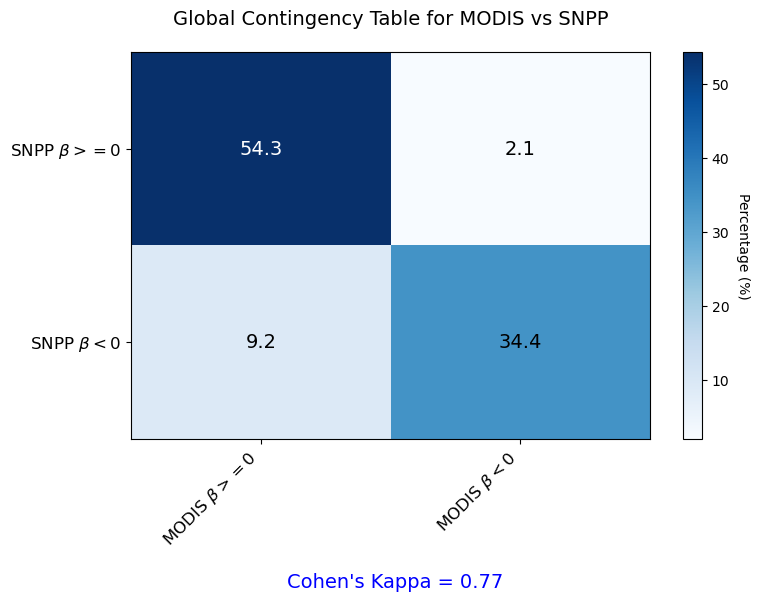

In [50]:
# 2x2 Table
plot_contingency_table(
    contingency_table_2x2,
    col_labels_2x2,
    row_label_2x2,
    title=f"Global Contingency Table for {source1.upper()} vs {source2.upper()}",
    kappa=kappa_2x2,
    cmap="Blues"
)

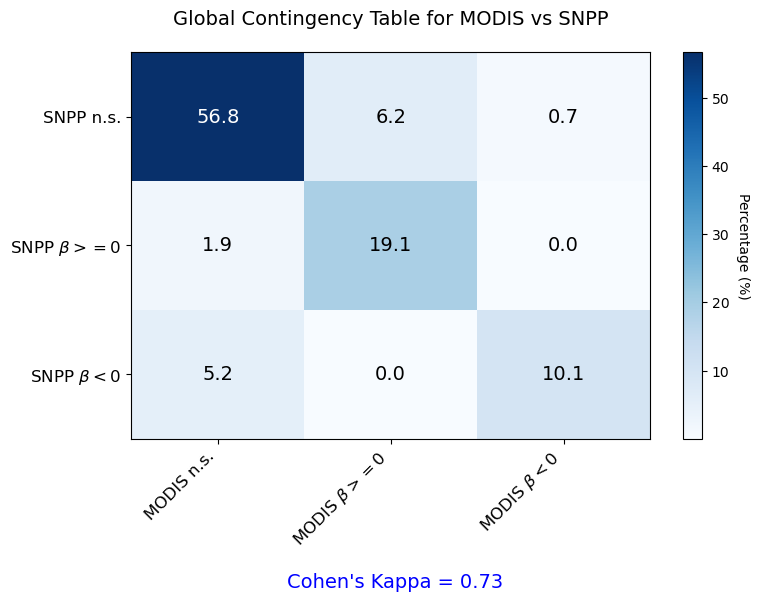

In [51]:
# 3 x 3 Table
plot_contingency_table(
    contingency_table_3x3,
    col_labels_3x3,
    row_label_3x3,
    title=f"Global Contingency Table for {source1.upper()} vs {source2.upper()}",
    kappa=kappa_3x3,
    cmap="Blues"
)

## Results:
- **Agreement between MODIS and NOAA20**:

    - The **2x2 contingency table** shows **82.3% agreement** for positive trends.
    
    - The **3x3 table** shows **66.0% agreement** for non-significant trends.

- **Cohen's Kappa Values**:

    - **2x2 Kappa**: 0.72 (strong agreement)

    - **3x3 Kappa**: 0.77 (strong agreement)